## Resume Screening using Deep Learning

### Problem Statement:
The goal of this project is to automatically classify resumes into job categories using Natural Language Processing (NLP) and Deep Learning.

#### This Project uses:
 + ##### Text Preprocessing
 + ##### Tokenization
 + ##### Deep Learning (BiLSTM)
 + ##### Streamlit deployment

#### Objective:
Given a resume, the model predicts the most suitable job category.

### Step 1: IMPORT LIBRARIES

In [1]:
# ==============================
# Import Required Libraries
# ==============================

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import re
import pickle

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# NLP & Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Deep Learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    Bidirectional,
    LSTM,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import EarlyStopping


### Step 2: LOAD DATASET

In this step, we load the resume dataset from the data folder.
Each row represents one resume and its corresponding job category.

In [2]:
# Load Dataset
df = pd.read_csv("../data/Resume.csv")

# Display first 5 rows
df.head()
    

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


### Step 3: DATA UNDERSTANDING
In this step, we analyze:
- dataset shape
- column names
- missing values
- category distribution

This helps us understand the quality and structure of the data before preprocessing.

In [3]:
# Dataset shape
print("Dataset Shape",df.shape)

# Column names
print("\nColumns:")
print(df.columns)

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape (2484, 4)

Columns:
Index(['ID', 'Resume_str', 'Resume_html', 'Category'], dtype='object')

Missing Values:
ID             0
Resume_str     0
Resume_html    0
Category       0
dtype: int64


In [4]:
# Count job categories
category_counts = df['Category'].value_counts()

print(category_counts)

Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
FINANCE                   118
ADVOCATE                  118
ACCOUNTANT                118
ENGINEERING               118
CHEF                      118
AVIATION                  117
FITNESS                   117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64


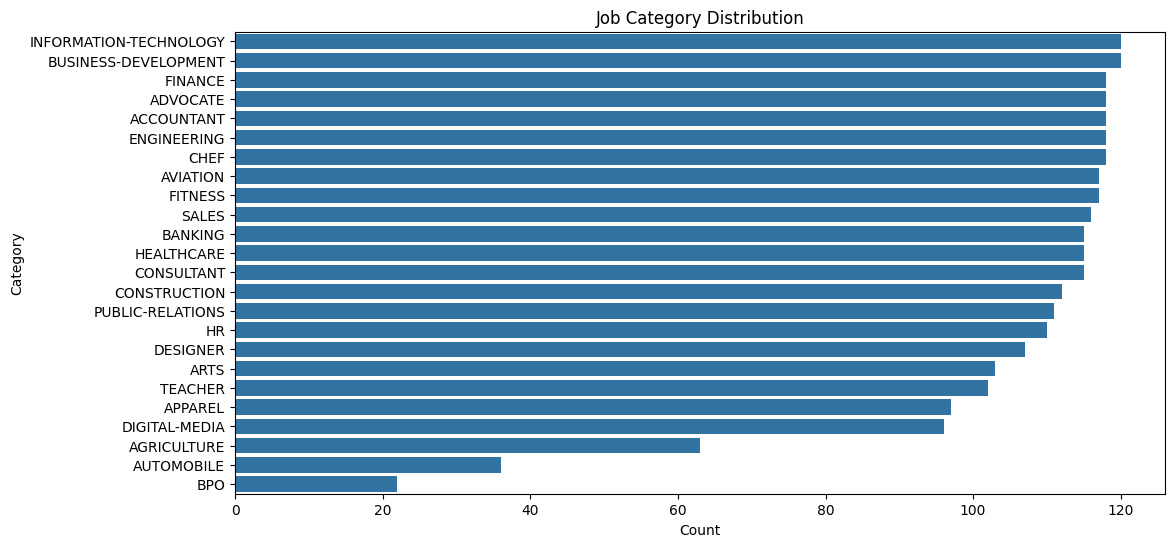

In [5]:
# VISUALIZE CATEGORY DISTRIBUTION

plt.figure(figsize=(12,6))

sns.countplot(
    y=df["Category"],
    order=df["Category"].value_counts().index
)

plt.title("Job Category Distribution")
plt.xlabel("Count")
plt.ylabel("Category")

plt.show()

##### “Analyzed the dataset structure, checked for missing values, and studied category distribution before preprocessing. This helps identify class imbalance and data quality issues.”

### Step 4: DATA PREPROCESSING (Text Cleaning & Encoding)

Raw resume text contains:
- URLs
- punctuation
- numbers
- special characters
- inconsistent spacing

These do not help the model learn meaningful patterns.

In this step, the text are cleaned before tokenization.

In [6]:
# ===================================
# Text Cleaning
# ===================================

def clean_text(text):

    # Convert text to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)

    # Remove special characters and numbers
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [7]:
# Applying cleaning function
df["clean_resume"] = df["Resume_str"].apply(clean_text)

# Display cleaned text
df[["Resume_str", "clean_resume"]].head()

,Resume_str,clean_resume
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,hr administrator marketing associate hr admini...
1,"HR SPECIALIST, US HR OPERATIONS ...",hr specialist us hr operations summary versati...
2,HR DIRECTOR Summary Over 2...,hr director summary over years experience in r...
3,HR SPECIALIST Summary Dedica...,hr specialist summary dedicated driven and dyn...
4,HR MANAGER Skill Highlights ...,hr manager skill highlights hr skills hr depar...


In [8]:
# Original Resume vs Cleaned Resume comparison

print("Original Resume:\n")
print(df["Resume_str"][0])

print("\n" + "="*80 + "\n")

print("Cleaned Resume:\n")
print(df["clean_resume"][0])

Original Resume:

         HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commitment to customer service.         Highlights         Focused on customer satisfaction  Team management  Marketing savvy  Conflict resolution techniques     Training and development  Skilled multi-tasker  Client relations specialist           Accomplishments      Missouri DOT Supervisor Training Certification  Certified by IHG in Customer Loyalty and Marketing by Segment   Hilton Worldwide General Manager Training Certification  Accomplished Trainer for cross server hospitality systems such as    Hilton OnQ  ,   Micros    Opera PMS   , Fidelio    OPERA    Reservation System (ORS) ,   Holidex    Completed courses and seminars in customer service, sales strategies, inventory c

In [9]:
# ===================================
# Label Encoding
# ===================================

le = LabelEncoder()

# Convert category names into numbers
df["label"] = le.fit_transform(df["Category"])

# Display encoded labels
df[["Category", "label"]].head()

,Category,label
0,HR,19
1,HR,19
2,HR,19
3,HR,19
4,HR,19


In [10]:
# Unique labels
print("Unique Labels:")
print(df["label"].unique())

# Number of classes
print("\nNumber of Classes:")
print(df["label"].nunique())

Unique Labels:
[19 13 20 23  1  9 18 17  2  8 22 12 14  5 10 16  3 15  0 11 21  7  4  6]

Number of Classes:
24


In [11]:
# Save label mapping
label_mapping = dict(                  # Creates a dictionary eg: { 'Chef': 0, 'Data Science': 1 }
    zip(le.classes_,                   # Model remembers which number belongs to which job category
        le.transform(le.classes_))
)

print(label_mapping)



{'ACCOUNTANT': 0, 'ADVOCATE': 1, 'AGRICULTURE': 2, 'APPAREL': 3, 'ARTS': 4, 'AUTOMOBILE': 5, 'AVIATION': 6, 'BANKING': 7, 'BPO': 8, 'BUSINESS-DEVELOPMENT': 9, 'CHEF': 10, 'CONSTRUCTION': 11, 'CONSULTANT': 12, 'DESIGNER': 13, 'DIGITAL-MEDIA': 14, 'ENGINEERING': 15, 'FINANCE': 16, 'FITNESS': 17, 'HEALTHCARE': 18, 'HR': 19, 'INFORMATION-TECHNOLOGY': 20, 'PUBLIC-RELATIONS': 21, 'SALES': 22, 'TEACHER': 23}


##### “The trained model predicts encoded numerical labels, so we saved the label mapping to convert predictions back into human-readable job categories during deployment.”

### Step 5: TRAIN-TEST-SPLIT
The dataset is divided into:
- Training data
- Testing data

Training data is used to train the model.
Testing data is used to evaluate model performance on unseen resumes.

In [12]:
# ===================================
# Features and Target
# ===================================

X = df["clean_resume"]       # Feature
y = df["label"]              # Target

# ===================================
# Train-Test Split
# ===================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 1987
Testing Samples: 497


### Step 6: TOKENIZATION AND PADDING (Feature Encoding for NLP)

Deep learning models cannot process raw text directly.

Therefore:
1. Tokenization converts words into numbers.
2. Padding makes all sequences equal length.

This prepares text data for the BiLSTM model.

In [13]:
# ===================================
# Tokenization
# ===================================

VOCAB_SIZE = 5000                             # Keeping only the top 5000 most common words
MAX_LEN = 150                                 # Every Resume will become exact 150 words

tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,                     # Tokenizer only keeps 5000 words
    oov_token="<OOV>"                         # If tokenizer sees unknown word, it replaces with <OOV>. (OOV → Out of Vocabulary)
)

# Learn vocabulary ONLY from training data
tokenizer.fit_on_texts(X_train)               # Prevents Data leakage

# Convert text to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)   # This converts words → numbers. "python sql developer" becomes [1, 4, 8].
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Padding
X_train = pad_sequences(
    X_train_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_test = pad_sequences(
    X_test_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)

X_train Shape: (1987, 150)
X_test Shape: (497, 150)


📌 What is Vocabulary?

Vocabulary means: Unique words in dataset. Eg: python, sql, machine, learning, data etc... Each gets an ID.

📌 tokenizer.fit_on_texts (X_train) ?

This teaches tokenizer the words from training data. Tokenizer will read all resumes then count words and then creates dictionary.

Eg: "I know python and sql"

"I love python"

Tokenizer creates: { "python":1, "i":2, "know":3, "sql":4,"love":5 }

❌ Neural networks requires fixed input size, but resumes have different lengths. Eg: Resume 1 → 50 words, Resume 2 → 250 words, Resume 3 → 180 words etc..

Problem: Neural networks cannot handle varying lengths directly.

📌 What does Padding do?

Suppose [12,34,26] becomes [12,34,26,0,0,0], now all inputs will have same length

📌 Why MAX_LEN = 150?

This means: Each resume becomes 150 tokens long. 

Short resumes → padded with zeros

Long resumes → truncated

📌 Why padding="post"?

Padding added at END:

[1,2,3,0,0] instead of [0,0,1,2,3]

Suppose the original text is "python sql machine learning", Tokenizer converts it into: [45, 12, 98, 76] so that neural networks can process it.

### Step 7: BUILD THE BiLSTM MODEL
In this step, we create a BiLSTM-based neural network for resume classification.
- dropout is used to reduce overfitting
- softmax activation is used for multi-class classification

In [14]:
# ===================================
# Build BiLSTM Model
# ===================================

NUM_CLASSES = df['label'].nunique()       # counts how many unique job categories the dataset have.

model = Sequential()

# Embedding Layer                         # Understanding word meanings
model.add(
    Embedding(
        input_dim = VOCAB_SIZE,           # Vocabulary of 10000 unique words in dataset (VOCAB_SIZE = 10000)
        output_dim = 64,                  # Each word becomes 64-dimensional vector (vector of 64 values)
        input_length = MAX_LEN            # Each resume has 150 tokens (MAX_LEN = 150)
    )
)

# Bidirectional LSTM                      # Understand word order and context
model.add(
    Bidirectional(
        LSTM(32)                          # 32 memory cells
    )
)

# Dropout Layer                           # 50% neurons randomly turned off to prevent overfitting
model.add(
    Dropout(0.5)
)


# Output Layer
model.add(
    Dense(NUM_CLASSES, activation = "softmax")    # "softmax" converts output (job categories) into probabilities. Eg: Data Science → 0.82, HR → 0.14, Chef → 0.04
)

# Compile Model                                   # Model Training
model.compile(
    loss = "sparse_categorical_crossentropy",     # used for multi-class classification when labels are integers.
    optimizer  = "adam",                          # Optimizer for DL (adjusts weight accordingly)
    metrics = ["accuracy"]
)

# Display model summary
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 150, 64)           320000    
                                                                 
 bidirectional (Bidirectiona  (None, 64)               24832     
 l)                                                              
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense (Dense)               (None, 24)                1560      
                                                                 
Total params: 346,392
Trainable params: 346,392
Non-trainable params: 0
_________________________________________________________________


##### Sequential: Creates layer-by-layer neural network
##### Embedding Layer
Tokenizer gives: Word IDs (python → 45, sql → 12)

Embedding converts Word IDs → Dense vectors. Eg: 45 → [0.23, -0.11, 0.88 ...]

This helps model learn: semantic meaning & word relationships.

##### Bidirectional LSTM
BiLSTM stands for Bidirectional Long Short-Term Memory. It is an advanced type of Recurrent Neural Network (RNN) designed to process sequential data in both directions.

BiLSTM reads: 

Left → Right
AND
Right → Left

This improves context understanding and sentence meaning capture.

##### Started with Embedding layer to convert tokenized resume text into dense word representations. Then used Bidirectional LSTM to capture context from both directions in the resume text. Dropout was added to reduce overfitting, and a Softmax output layer was used for multi-class job category prediction.

### Step 8: TRAIN THE MODEL
In this step:
- the model learns from training data
- validation performance is monitored
- EarlyStopping is used to prevent overfitting

In [15]:
# ===================================
# Early Stopping
# ===================================

early_stopping = EarlyStopping(           # Stop training automatically when performance stops improving
    monitor="val_loss",                   # Wathches validation loss
    patience=3,                           # Training stops when validation loss does not improve for 3 consecutive epochs
    restore_best_weights=True,            # Restores Best-performing weights automatically
)

# =================================== 
# Train Model
# ===================================

history = model.fit(
    X_train,
    y_train,

    validation_data=(X_test, y_test),

    epochs=20,
    batch_size=32,

    callbacks=[early_stopping]
)

Epoch 1/20
63/63 [==============================] - 13s 110ms/step - loss: 3.1481 - accuracy: 0.1570 - val_loss: 3.0816 - val_accuracy: 0.2998
Epoch 2/20
63/63 [==============================] - 5s 82ms/step - loss: 2.9320 - accuracy: 0.2572 - val_loss: 2.7515 - val_accuracy: 0.3944
Epoch 3/20
63/63 [==============================] - 5s 85ms/step - loss: 2.5135 - accuracy: 0.3528 - val_loss: 2.3535 - val_accuracy: 0.4608
Epoch 4/20
63/63 [==============================] - 6s 96ms/step - loss: 2.0290 - accuracy: 0.4952 - val_loss: 1.9216 - val_accuracy: 0.5594
Epoch 5/20
63/63 [==============================] - 5s 81ms/step - loss: 1.6084 - accuracy: 0.6044 - val_loss: 1.6528 - val_accuracy: 0.6197
Epoch 6/20
63/63 [==============================] - 5s 85ms/step - loss: 1.3156 - accuracy: 0.7026 - val_loss: 1.4482 - val_accuracy: 0.6700
Epoch 7/20
63/63 [==============================] - 5s 81ms/step - loss: 1.0734 - accuracy: 0.7539 - val_loss: 1.3976 - val_accuracy: 0.6761
Epoch 8/20


In [16]:
best_val_acc = max(history.history["val_accuracy"])
best_train_acc = max(history.history["accuracy"])

print("Best Training Accuracy:", best_train_acc)
print("Best Validation Accuracy:", best_val_acc)

Best Training Accuracy: 0.9280322194099426
Best Validation Accuracy: 0.7022132873535156


### Step 9: MODEL EVALUATION
In this step:
- predictions are generated
- classification report is analyzed
- confusion matrix is visualized

This helps evaluate model performance across all job categories.

#### Step 9.1: Generate Predictions

In [17]:
# ===================================
# Generate Predictions
# ===================================

y_pred_probs = model.predict(X_test)              # Returns probabilities

# Convert probabilities into class labels
y_pred = np.argmax(y_pred_probs, axis=1)          # argmax(): returns index of highest probability

print("Prediction Shape:", y_pred.shape)

16/16 [==============================] - 2s 37ms/step
Prediction Shape: (497,)


#### Step 9.2: Classification Report

In [18]:
from sklearn.metrics import classification_report

# ===================================
# Classification Report
# ===================================

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      0.92      0.96        24
           1       0.48      0.67      0.56        24
           2       0.00      0.00      0.00        13
           3       0.30      0.16      0.21        19
           4       0.50      0.33      0.40        21
           5       0.00      0.00      0.00         7
           6       0.43      0.54      0.48        24
           7       0.33      0.43      0.38        23
           8       0.00      0.00      0.00         4
           9       0.83      1.00      0.91        24
          10       0.94      0.71      0.81        24
          11       0.76      0.73      0.74        22
          12       0.87      0.87      0.87        23
          13       0.86      0.86      0.86        21
          14       0.58      0.58      0.58        19
          15       0.92      1.00      0.96        24
          16       0.92      1.00      0.96        24
          17       0.41    

#### Step 9.3: Confusion Matrix

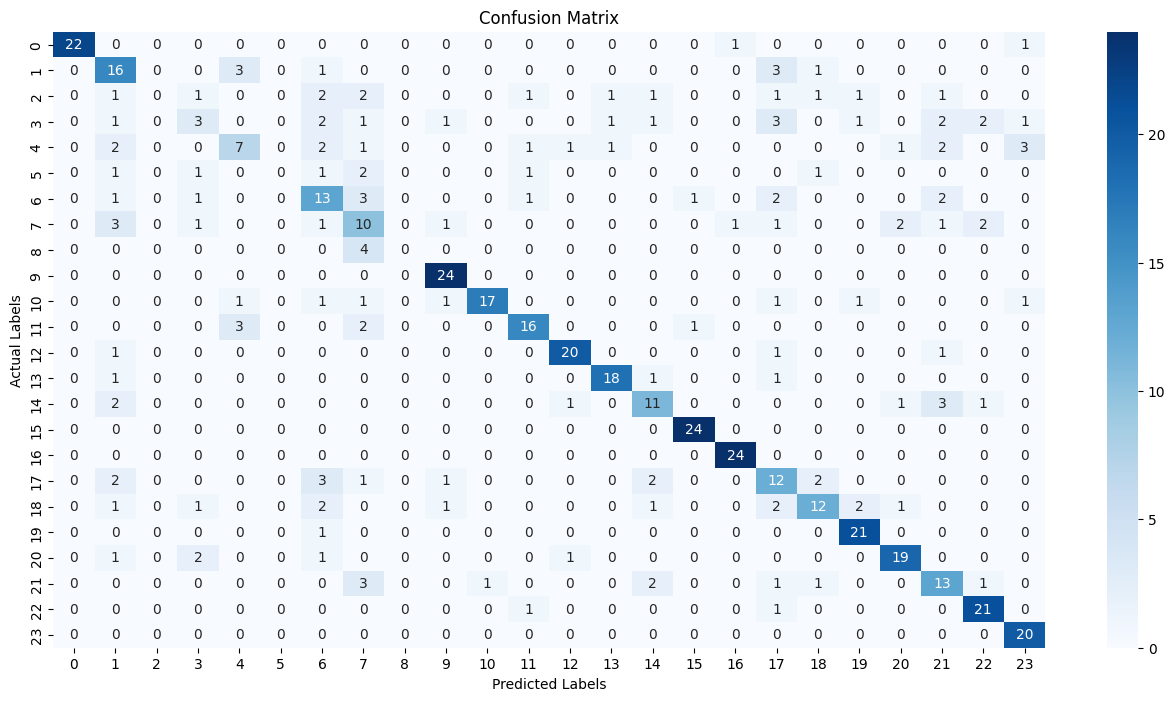

In [19]:
from sklearn.metrics import confusion_matrix

# ===================================
# Confusion Matrix
# ===================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(16,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("Actual Labels")

plt.show()

“The confusion matrix helps visualize class-wise prediction performance and identify which job categories the model confuses most often.”

### Step 10: BASELINE MODEL: TF-IDF + LOGISTIC REGRESSION
Deep learning models are not always the best first choice for text classification.
In this step, a traditional NLP baseline is build using TF-IDF and Logistic Regression.
This helps to compare whether the deep learning model is actually better than a simpler machine learning model.

In [20]:
# Importing Required Libraries

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

#### Step 10.1: Train-Test-Split

In [21]:
# ===================================
# Train-Test Split for Text Data
# ===================================

X_text = df["clean_resume"]
y = df["label"]

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Text train-test split completed!")

Text train-test split completed!


#### Step 10.2: Build TF-IDF + Logistic Regression Model

In [22]:
# ===================================
# TF-IDF + Logistic Regression Model
# ===================================

tfidf_lr_model = Pipeline([
    ("tfidf", TfidfVectorizer(                # Converts text to numerical features
        max_features=10000,  
        ngram_range=(1, 2),                   # Model uses single words + two-word phrases. Eg: python, machine learning, data analysis 
        stop_words="english"                  # Removes common words like the, and, is, with etc...
    )),
    
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"               # This helps weaker/smaller categories get more attention
    ))
])

TfidfVectorizer : This converts text into numerical features.

Unlike tokenizer, TF-IDF checks: "Which words are important in each resume?"

#### Step 10.3: Train the Baseline Model

In [23]:
# Train model
tfidf_lr_model.fit(X_train_text,y_train)

print("TF-IDF Logistic Regression model trained successfully!")

TF-IDF Logistic Regression model trained successfully!


#### Step 10.4: Evaluate the Baseline Model

In [24]:
# Predict on test data
y_pred_lr = tfidf_lr_model.predict(X_test_text)

# Accuracy
lr_accuracy = accuracy_score(y_test, y_pred_lr)

print("TF-IDF + Logistic Regression Accuracy:", lr_accuracy)

TF-IDF + Logistic Regression Accuracy: 0.6619718309859155


#### Step 10.5: Print Classification Report

In [25]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.65      0.83      0.73        24
           1       0.42      0.46      0.44        24
           2       0.64      0.54      0.58        13
           3       0.57      0.21      0.31        19
           4       0.62      0.38      0.47        21
           5       0.57      0.57      0.57         7
           6       0.84      0.67      0.74        24
           7       0.79      0.65      0.71        23
           8       0.67      0.50      0.57         4
           9       0.51      0.83      0.63        24
          10       0.85      0.71      0.77        24
          11       0.77      0.77      0.77        22
          12       0.50      0.17      0.26        23
          13       0.85      0.81      0.83        21
          14       0.71      0.53      0.61        19
          15       0.72      0.75      0.73        24
          16       0.89      0.71      0.79        24
          17       0.94    

##### BiLSTM has accuracy of 0.70 while TF-IDF+LR has only accuracy of 0.66 indicating BiLSTM is better.

### Step 11: Save Model and Artifacts

In [26]:
# ===================================
# Save Model
# ===================================

model.save("../models/resume_screening_model.keras")

print("Model saved successfully!")

Model saved successfully!


### Step 12: Save Tokenizer and Label Mapping

In [27]:
# Save tokenizer
with open("../artifacts/tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

print("Tokenizer saved successfully!")

Tokenizer saved successfully!


In [28]:
# Save label mapping
label_mapping = dict(
    zip(le.classes_,
        le.transform(le.classes_))
)

with open("../artifacts/label_mapping.pkl", "wb") as f:
    pickle.dump(label_mapping, f)

print("Label mapping saved successfully!")

Label mapping saved successfully!
